# Extract variables at bottom of ocean: an example with Age

This notebook shows a simple example of plotting ocean Ideal Age. Ideal Age is a fictitious tracer which is set to zero in the surface grid-cell every timestep, and is aged by 1 year per year otherwise. It is a useful proxy for nutrients, such as carbon or oxygen (but not an exact analogue). 

One of the interesting aspects of age is that we can use it to show pathways of the densest water in the ocean by plotting a map of age in the lowest grid cell. This plot requires a couple of tricks to extract information from the lowest cell.



Compute times were calculated using the (24 cpus, 95 Gb mem) Jupyter Lab on NCI's Gadi with conda environment analysis3-25.07 or above.


**Conversion for MOM6:** This notebook uses ACCESS-OM2 (MOM5) data. To convert this notebook for extracting tracer variables at the bottom of the ocean with ACCESS-OM3 or other MOM6 models, there are some variable names that would need to be changed: \
    - we would replace ``st_ocean`` with the vertical coordinate of MOM6 data which is usually ``z_l`` \
    - we would replace ``ht`` with the depth variable ``deptho`` \
    - the ideal age variable in MOM6 is ``agessc``


In [1]:
import intake
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

import cartopy.crs as ccrs
import cmocean as cm

from dask.distributed import Client

In [2]:
client = Client(threads_per_worker = 1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34231,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34871,Total threads: 1
Dashboard: /proxy/46621/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:44085,


2026-07-01 16:00:21,038 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle ef33bb80b017568def52fa9cadc8450e initialized by task ('rechunk-merge-rechunk-transfer-67a0106ae1c0a72625c1c3489af3d863', 0, 0, 3, 8, 0, 5, 3, 8) executed on worker tcp://127.0.0.1:41641
2026-07-01 16:00:21,139 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 36c706b679abb303c44342e2e4142718 initialized by task ('rechunk-merge-rechunk-transfer-67a0106ae1c0a72625c1c3489af3d863', 1, 0, 3, 7, 1, 5, 3, 7) executed on worker tcp://127.0.0.1:46055
2026-07-01 16:00:21,453 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 953c04d8a1cdb41634551a9fd8f04d57 initialized by task ('rechunk-merge-rechunk-transfer-67a0106ae1c0a72625c1c3489af3d863', 0, 0, 3, 7, 0, 5, 3, 7) executed on worker tcp://127.0.0.1:44989
2026-07-01 16:00:21,460 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle aacd8f1e36e4cf4a9991bd2984682b57 initialized by task ('rechunk-merge-rechunk-transfer-67a0106ae1c0a72625c1

Add a database session. No database file has been specified so it will use the default database that indexes a number of COSIMA datasets

In [3]:
catalog = intake.cat.access_nri

Now, let's set the experiment and time interval, and average ideal age over a year.

In [14]:
experiment = '01deg_jra55v13_ryf9091'
variable = 'age_global'
start_time = '2099-01-01'
end_time   = '2099-12-31'

ds_age = catalog[experiment].search(variable=variable, frequency='1mon').to_dask()
age = ds_age[variable].sel(time=slice(start_time, end_time))
age

<xarray.DataArray 'age_global' (time: 12, st_ocean: 75, yt_ocean: 2700,
                                xt_ocean: 3600)> Size: 35GB
dask.array<getitem, shape=(12, 75, 2700, 3600), dtype=float32, chunksize=(2, 14, 600, 800), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) object 96B 2099-01-16 12:00:00 ... 2099-12-16 12:00:00
  * st_ocean  (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
Attributes:
    long_name:      Age (global)
    units:          yr
    valid_range:    [0.e+00 1.e+20]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_water_age_since_surface_contact

In [15]:
# Perhaps, there's a better way to chunk the variable but this works fine, too
chunks_dict = {
    'xt_ocean': 360,
    'yt_ocean': 300, 
    'st_ocean': 75, 
    'time': '250Mb'
}
age = age.chunk(chunks_dict)
age

<xarray.DataArray 'age_global' (time: 12, st_ocean: 75, yt_ocean: 2700,
                                xt_ocean: 3600)> Size: 35GB
dask.array<rechunk-p2p, shape=(12, 75, 2700, 3600), dtype=float32, chunksize=(6, 75, 300, 360), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) object 96B 2099-01-16 12:00:00 ... 2099-12-16 12:00:00
  * st_ocean  (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
Attributes:
    long_name:      Age (global)
    units:          yr
    valid_range:    [0.e+00 1.e+20]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_water_age_since_surface_contact

The age variable is a 4D variable. There are a number of ways to extract the value at the bottom of the ocean. This notebook outlines two ways this can be achieved: *(i)* using masking and using *(ii)* indexing.

In this case masking is much slower than indexing, but for some use cases this has been the opposite. The masking approach has the benefit of not requiring the depth grid information.

## I. Masking approach

Create a mask of all the bottom cells. Can achieve this by taking the data, shift it up one cell in the vertical grid, find all non-NAN cells, and then negate this mask. Then mask the same data with with this mask, which will select out only the lowest level of non-NAN values in the data.

In a second step turn it into a boolean array for neatness.

In [16]:
bottom_mask = age.isel(time=1).where(~np.isfinite(age.isel(time=1).shift({'st_ocean': -1})))
bottom_mask = ~np.isnan(bottom_mask)
bottom_mask

<xarray.DataArray 'age_global' (st_ocean: 75, yt_ocean: 2700, xt_ocean: 3600)> Size: 729MB
dask.array<invert, shape=(75, 2700, 3600), dtype=bool, chunksize=(75, 300, 360), chunktype=numpy.ndarray>
Coordinates:
  * st_ocean  (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
    time      object 8B 2099-02-15 00:00:00
Attributes:
    long_name:      Age (global)
    units:          yr
    valid_range:    [0.e+00 1.e+20]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_water_age_since_surface_contact

In [17]:
%%time
bottom_age = age.where(bottom_mask).sum(dim='st_ocean', skipna=True, min_count=1)
bottom_age_mean = bottom_age.mean('time').compute()
bottom_age_mean

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 9.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 20.4 s, sys: 8.2 s, total: 28.6 s
Wall time: 31.4 s


<xarray.DataArray 'age_global' (yt_ocean: 2700, xt_ocean: 3600)> Size: 39MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(2700, 3600), dtype=float32)
Coordinates:
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
Attributes:
    long_name:      Age (global)
    units:          yr
    valid_range:    [0.e+00 1.e+20]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_water_age_since_surface_contact

Load some things we need for plotting. Bathymetry for plotting the land mask, and lat/lon:

In [18]:
bathymetry = catalog[experiment].search(variable='ht',
                                        frequency='fx').to_dask()['ht']

land = xr.where(np.isnan(bathymetry.rename('land')), 1, np.nan)
land 

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


<xarray.DataArray 'land' (yt_ocean: 2700, xt_ocean: 3600)> Size: 78MB
dask.array<where, shape=(2700, 3600), dtype=float64, chunksize=(2700, 3600), chunktype=numpy.ndarray>
Coordinates:
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
    geolon_t  (yt_ocean, xt_ocean) float32 39MB dask.array<chunksize=(2700, 3600), meta=np.ndarray>
    geolat_t  (yt_ocean, xt_ocean) float32 39MB dask.array<chunksize=(2700, 3600), meta=np.ndarray>

Although, ``ht`` loaded from ``intake`` already has ``geolon_t`` and ``geolat_t`` coordinates, we can't not use them for plotting because they contain NaN values over the continents. So we still have to load geolon_t & geolat_t from the grid file and assign them to ``land`` and ``bottom_age_mean`` prior to producing a figure. 

In [27]:
ds = xr.open_dataset("/g/data/ik11/grids/ocean_grid_01.nc")
ds = ds.rename(
    {
        "grid_x_C": "xu_ocean",
        "grid_y_C": "yu_ocean",
        "grid_x_T": "xt_ocean",
        "grid_y_T": "yt_ocean",
    }
)
geolon_t = ds.geolon_t
geolat_t = ds.geolat_t

In [29]:
land = land.drop_vars(['geolon_t', 'geolat_t'])
land = land.assign_coords({'geolon_t': geolon_t, 'geolat_t': geolat_t})
bottom_age_mean = bottom_age_mean.assign_coords({'geolon_t': geolon_t, 'geolat_t': geolat_t})

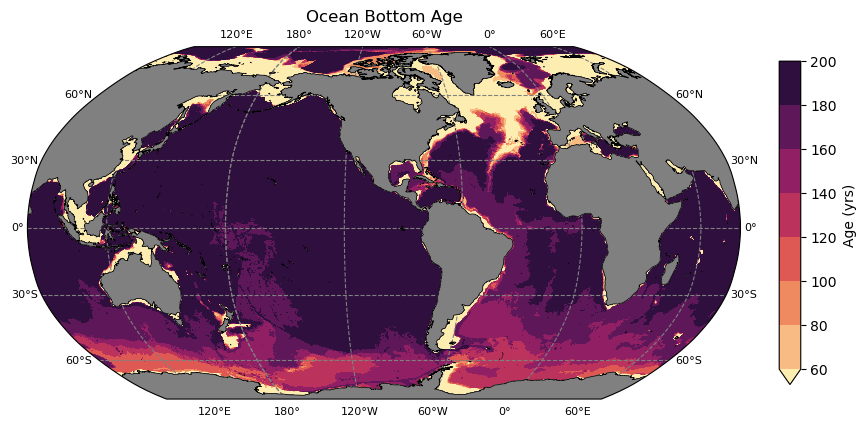

In [30]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=-100)) 

gl=ax.gridlines(draw_labels=True, linestyle='--', color='grey', x_inline=False, y_inline=False)
ax.spines['geo'].set_visible(True)
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}


# Add model land mask
land.plot.contourf(ax=ax,
                   x="geolon_t",
                   y="geolat_t",
                   colors="grey",
                   zorder=2, transform=ccrs.PlateCarree(), add_colorbar=False
                )

# Add model coastline
land.fillna(0).plot.contour(ax=ax,
                            x="geolon_t",
                            y="geolat_t",
                            colors="k",
                            levels=[0, 1],
                            transform=ccrs.PlateCarree(), add_colorbar=False,
                            linewidths=0.5,
                        )

bottom_age_mean.plot.contourf(ax=ax,
                              x="geolon_t",
                              y="geolat_t",
                              cmap=cm.cm.matter,
                              vmin=60,
                              vmax=200,
                              transform=ccrs.PlateCarree(),
                              levels=8,
                              cbar_kwargs={"label": "Age (yrs)", "fraction": 0.03, "aspect": 15, "shrink": 0.7})

plt.title('Ocean Bottom Age');

## II. Indexing approach

Here we grab the `kmt` variable out of `ocean_grid.nc`. The `kmt` variable tells us the lowest cell which is active at each $(x, y)$ location.

In [31]:
kmt = catalog[experiment].search(variable='kmt',
                                 frequency='fx').to_dask()['kmt']
kmt = kmt.fillna(1.0).astype(int) - 1
kmt.load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


<xarray.DataArray 'kmt' (yt_ocean: 2700, xt_ocean: 3600)> Size: 78MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2700, 3600))
Coordinates:
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
    geolon_t  (yt_ocean, xt_ocean) float32 39MB nan nan nan nan ... nan nan nan
    geolat_t  (yt_ocean, xt_ocean) float32 39MB nan nan nan nan ... nan nan nan
Attributes:
    long_name:     number of depth levels on t-grid
    units:         dimensionless
    valid_range:   [-1.e+01  1.e+09]
    cell_methods:  time: point

Provided that `kmt` is loaded, `xarray` is smart enough to figure out what this line means, and extracts a 2-D field of bottom age for us.

In [41]:
%%time
bottom_age = age.mean('time').isel(st_ocean=kmt)
bottom_age_mean = bottom_age.compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 93.14 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 43 s, sys: 22.1 s, total: 1min 5s
Wall time: 59.9 s


Assign ``geolon_t`` and ``geolat_t`` from the grid file to ``bottom_age_mean``

In [42]:
bottom_age_mean = bottom_age_mean.assign_coords({'geolon_t': geolon_t, 'geolat_t': geolat_t})

And here is the plot:

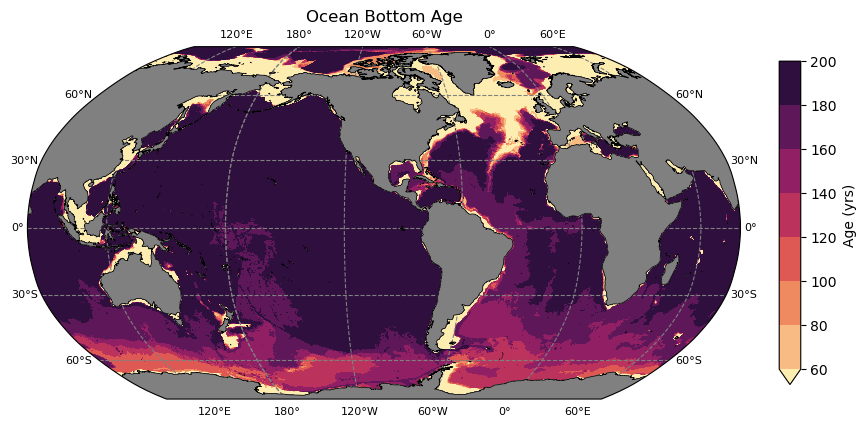

In [43]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=-100))

gl=ax.gridlines(draw_labels=True, linestyle='--', color='grey', x_inline=False, y_inline=False)
ax.spines['geo'].set_visible(True)
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}

# Add model land mask
land.plot.contourf(ax=ax,
                   x='geolon_t', y='geolat_t',
                   colors='grey',
                   zorder=2,
                   transform=ccrs.PlateCarree(),
                   add_colorbar=False)

# Add model coastline
land.fillna(0).plot.contour(ax=ax,
                            x='geolon_t', y='geolat_t',
                            colors='k',
                            levels=[0, 1],
                            transform=ccrs.PlateCarree(),
                            add_colorbar=False,
                            linewidths=0.5)


bottom_age_mean.plot.contourf(ax=ax,
                         x='geolon_t', y='geolat_t',
                         cmap=cm.cm.matter,
                         vmin=60,
                         vmax=200,
                         levels=8,
                         transform=ccrs.PlateCarree(),
                         cbar_kwargs={"label": "Age (yrs)", "fraction": 0.03, "aspect": 15, "shrink": 0.7})

plt.title('Ocean Bottom Age');

## Some remarks

A few things to note here:
* The continental shelves are all young - this is just because they are shallow.
* The North Atlantic is also relatively young, due to formation of NADW. Note that both the Deep Western Boundary Currents and the Mid-Atlantic Ridge both sustain southward transport of this young water.
* A signal following AABW pathways (northwards at the western boundaries) shows slightly younger water in these regions, but it has mixed somewhat with older water above.
* Even after 200 years, the water in the NE Pacific has not experienced any ventilation...

## Notes on performance

The indexing method requires the data to be loaded into memory and appears faster than it actually is if this isn't factored in. Calculations with large datasets that do not fit within memory will struggle in this case.

The indexing method does not perform well in a `dask` workflow where lazy loading is being used. 

The masking approach does not suffer from these limitations and when in doubt should be the preferred method. It also has the advantage of not requiring the grid data.

To illustrate this: a single month of bottom age from the original data using masking

In [44]:
%%time
age.isel(time=1).where(bottom_mask).sum(dim='st_ocean').compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 9.74 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 11.5 s, sys: 4.51 s, total: 16 s
Wall time: 16.6 s


<xarray.DataArray 'age_global' (yt_ocean: 2700, xt_ocean: 3600)> Size: 39MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(2700, 3600), dtype=float32)
Coordinates:
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
    time      object 8B 2099-02-15 00:00:00
Attributes:
    long_name:      Age (global)
    units:          yr
    valid_range:    [0.e+00 1.e+20]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_water_age_since_surface_contact

The same with indexing (different month to ensure no caching effects) is significantly slower

In [45]:
%%time
age.isel(time=3).isel(st_ocean=kmt).compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 93.14 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 35 s, sys: 18.9 s, total: 53.9 s
Wall time: 45.6 s


<xarray.DataArray 'age_global' (yt_ocean: 2700, xt_ocean: 3600)> Size: 39MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(2700, 3600), dtype=float32)
Coordinates:
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
    st_ocean  (yt_ocean, xt_ocean) float64 78MB 0.5413 0.5413 ... 0.5413 0.5413
    geolon_t  (yt_ocean, xt_ocean) float32 39MB nan nan nan nan ... nan nan nan
    geolat_t  (yt_ocean, xt_ocean) float32 39MB nan nan nan nan ... nan nan nan
    time      object 8B 2099-04-16 00:00:00
Attributes:
    long_name:      Age (global)
    units:          yr
    valid_range:    [0.e+00 1.e+20]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_water_age_since_surface_contact

It is much faster to preload the data and then index it, but this does rely on their being sufficient memory

In [46]:
%%time
myage = age.isel(time=4).load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 9.69 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 33.8 s, sys: 22 s, total: 55.7 s
Wall time: 48.8 s


In [47]:
%%time
myage.isel(st_ocean=kmt).compute()

CPU times: user 377 ms, sys: 99.8 ms, total: 476 ms
Wall time: 298 ms


<xarray.DataArray 'age_global' (yt_ocean: 2700, xt_ocean: 3600)> Size: 39MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(2700, 3600), dtype=float32)
Coordinates:
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
    st_ocean  (yt_ocean, xt_ocean) float64 78MB 0.5413 0.5413 ... 0.5413 0.5413
    geolon_t  (yt_ocean, xt_ocean) float32 39MB nan nan nan nan ... nan nan nan
    geolat_t  (yt_ocean, xt_ocean) float32 39MB nan nan nan nan ... nan nan nan
    time      object 8B 2099-05-16 12:00:00
Attributes:
    long_name:      Age (global)
    units:          yr
    valid_range:    [0.e+00 1.e+20]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_water_age_since_surface_contact